In [165]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as colors

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [166]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Week2

C:\Users\tr432\Downloads\filter_GutLungAxis_Week2


In [167]:
import pandas as pd

df_tax = pd.read_csv('gg2_family_table.tsv', sep='\t', skiprows=1, index_col='#OTU ID')
df_tax['Total'] = df_tax.sum(axis=1)
df_tax = df_tax.sort_values('Total', ascending=False)

meta = pd.read_csv('C:/Users/tr432/Downloads/filter_GutLungAxis_Control/RUN45_Metadata_GutLungAxis.txt', sep='\t')  ## csv일땐 sep='\t' 지워도 됨

print(df_tax.head(3))
print(meta.head(3))

                                                     C01-2w   C02-2w   C03-2w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac...    194.0    203.0     53.0   
d__Bacteria;p__Bacillota_A_368345;c__Clostridia...  15362.0  34889.0   8407.0   
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lact...  17922.0  13509.0  20365.0   

                                                     C09-2w   C10-2w   C11-2w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac...    198.0    399.0    182.0   
d__Bacteria;p__Bacillota_A_368345;c__Clostridia...  26129.0  47296.0  50231.0   
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lact...  36510.0  14491.0  13530.0   

                                                     V01-2w   V02-2w   V03-2w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonad

In [168]:
mapping = dict(zip(meta['#SampleID'].astype(str), meta['Group'].astype(str)))

df_tax2 = df_tax.copy()
df_tax2.columns = [mapping.get(c, None) for c in df_tax.columns[0:]]

df_tax2 = df_tax2.loc[:, [c for c in df_tax2.columns if c is not None]]

grouped = df_tax2.set_index(df_tax2.index).T.groupby(level=0).mean().T

grouped['Total'] = df_tax['Total']

grouped

,Control,VNAM,Total
#OTU ID,,,
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029,204.833333,61769.3,618922.0
d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae,30385.666667,79.2,183106.0
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Lactobacillaceae,19387.833333,5128.4,167611.0
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae,23313.333333,193.0,141810.0
d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae,5174.666667,19.1,31239.0
...,...,...,...
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Acholeplasmatales;__,0.333333,0.0,2.0
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Staphylococcales;__,0.333333,0.0,2.0
d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Acetivibrionales;f__DSM-27016,0.333333,0.0,2.0


In [169]:
for col in grouped.columns:
    print(col, sum(grouped[col]))

Control 102777.66666666667
VNAM 69689.5
Total 1313561.0


In [170]:
grouped.reset_index(inplace=True)
grouped

#grouped.to_csv("rel_gg2_genus_table_grouped.tsv", sep='\t', index=False)

,#OTU ID,Control,VNAM,Total
0,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,204.833333,61769.3,618922.0
1,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...,30385.666667,79.2,183106.0
2,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lac...,19387.833333,5128.4,167611.0
3,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,23313.333333,193.0,141810.0
4,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...,5174.666667,19.1,31239.0
...,...,...,...,...
82,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Ach...,0.333333,0.0,2.0
83,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Sta...,0.333333,0.0,2.0
84,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...,0.333333,0.0,2.0
85,d__Bacteria;p__Actinomycetota;c__Actinomycetes...,0.000000,0.2,2.0


In [171]:
new_cols = grouped['#OTU ID'].str.split(';', expand=True)
new_cols.columns = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 
#                    'Genus'
                    ]

df = pd.concat([new_cols, grouped], axis=1)
df = df.drop(columns=['#OTU ID'])

## 원하는 taxa level + 그룹명만 가져옴
cols = ['Phylum', 'Family', 
#        'Genus'
        ] + df.columns[5:].tolist()
df = df[cols]

df = df.replace('__', '_', regex=True)

df

,Phylum,Family,Control,VNAM,Total
0,p_Pseudomonadota,f_Enterobacteriaceae_A_725029,204.833333,61769.3,618922.0
1,p_Bacillota_A_368345,f_Lachnospiraceae,30385.666667,79.2,183106.0
2,p_Bacillota_I,f_Lactobacillaceae,19387.833333,5128.4,167611.0
3,p_Bacteroidota,f_Bacteroidaceae,23313.333333,193.0,141810.0
4,p_Bacillota_A_368345,f_Ruminococcaceae,5174.666667,19.1,31239.0
...,...,...,...,...,...
82,p_Bacillota_I,_,0.333333,0.0,2.0
83,p_Bacillota_I,_,0.333333,0.0,2.0
84,p_Bacillota_A_368345,f_DSM-27016,0.333333,0.0,2.0
85,p_Actinomycetota,f_Beutenbergiaceae,0.000000,0.2,2.0


In [172]:
df3 = df.copy()
df3['Phylum'] = df['Phylum'].str.replace(r'^p_', '', regex=True)
df3['Family'] = df['Family'].str.replace(r'^f_', '', regex=True)
#df3['Genus']  = df['Genus'] .str.replace(r'^g_', '', regex=True)

df3

,Phylum,Family,Control,VNAM,Total
0,Pseudomonadota,Enterobacteriaceae_A_725029,204.833333,61769.3,618922.0
1,Bacillota_A_368345,Lachnospiraceae,30385.666667,79.2,183106.0
2,Bacillota_I,Lactobacillaceae,19387.833333,5128.4,167611.0
3,Bacteroidota,Bacteroidaceae,23313.333333,193.0,141810.0
4,Bacillota_A_368345,Ruminococcaceae,5174.666667,19.1,31239.0
...,...,...,...,...,...
82,Bacillota_I,_,0.333333,0.0,2.0
83,Bacillota_I,_,0.333333,0.0,2.0
84,Bacillota_A_368345,DSM-27016,0.333333,0.0,2.0
85,Actinomycetota,Beutenbergiaceae,0.000000,0.2,2.0


In [173]:
df4 = df3.copy()

df4.head(25)

,Phylum,Family,Control,VNAM,Total
0,Pseudomonadota,Enterobacteriaceae_A_725029,204.833333,61769.3,618922.0
1,Bacillota_A_368345,Lachnospiraceae,30385.666667,79.2,183106.0
2,Bacillota_I,Lactobacillaceae,19387.833333,5128.4,167611.0
3,Bacteroidota,Bacteroidaceae,23313.333333,193.0,141810.0
4,Bacillota_A_368345,Ruminococcaceae,5174.666667,19.1,31239.0
5,Bacillota_A_368345,Oscillospiraceae_88309,4773.500000,5.3,28694.0
6,Bacillota_A_368345,CAG-508,2826.166667,4.3,17000.0
7,Bacteroidota,Muribaculaceae,2764.000000,7.7,16661.0
8,Verrucomicrobiota,Akkermansiaceae,2236.833333,13.6,13557.0
9,Pseudomonadota,Enterobacteriaceae_A_732334,0.000000,1095.0,10950.0


In [174]:
df5 = df4[
    df4['Family'].notna() &
    ~df4['Family'].str.strip().isin(['', '_'])
]

df5.head(25)

,Phylum,Family,Control,VNAM,Total
0,Pseudomonadota,Enterobacteriaceae_A_725029,204.833333,61769.3,618922.0
1,Bacillota_A_368345,Lachnospiraceae,30385.666667,79.2,183106.0
2,Bacillota_I,Lactobacillaceae,19387.833333,5128.4,167611.0
3,Bacteroidota,Bacteroidaceae,23313.333333,193.0,141810.0
4,Bacillota_A_368345,Ruminococcaceae,5174.666667,19.1,31239.0
5,Bacillota_A_368345,Oscillospiraceae_88309,4773.500000,5.3,28694.0
6,Bacillota_A_368345,CAG-508,2826.166667,4.3,17000.0
7,Bacteroidota,Muribaculaceae,2764.000000,7.7,16661.0
8,Verrucomicrobiota,Akkermansiaceae,2236.833333,13.6,13557.0
9,Pseudomonadota,Enterobacteriaceae_A_732334,0.000000,1095.0,10950.0


In [175]:
## Family Level - Relative Abundance로 변환 후 정렬


df6 = df5.copy()

num_cols = df6.columns[2:]
df6[num_cols] = df6[num_cols].div(df6[num_cols].sum(axis=0), axis=1)  #Edit: 이 줄을 주석처리하면 절대 풍부도 나타낼 수 있음 -> rev_26.02.16: Absolute Abundance (x) / Read Counts (o)


# 2-1. 상위 n개 기준: 각 taxon 의 전체 합
df6['rel_feature_sum'] = df6[num_cols].sum(axis=1)

# 2-2. Others 로 보낼 문자열 패턴 지정
banned_prefix = ['CAG', 'COE', 'UBA', 'HUN', 'UMGS', 'C-53']  #Edit: 바로 위 셀의 head(25) 결과 보고 직접 판단

# Family 기준으로 패턴 포함 여부
mask_banned = df6['Family'].str.upper().str.startswith(tuple(banned_prefix))

# 2-3. 상위 n개 (banned 는 제외하고 뽑기)
df_allowed = df6.loc[~mask_banned]
df_allowed = df_allowed.sort_values('Total', ascending=False)
top_idx = df_allowed.index[:8]  #Edit: 상위 몇개만 가져올지 선택

# 최종적으로 Others 로 갈 행
mask_top = df6.index.isin(top_idx)
mask_others = ~mask_top | mask_banned   # top n 밖이거나, banned 인 것들

# 2-4. 상위 n개만 남기기
df_top = df6.loc[~mask_others].copy()
df_top = df_top.sort_values('Total', ascending=False)
print(df_top['Control'].sum())
print(df_top['VNAM'].sum())

# 2-5. Others 행 만들기 (나머지 합)
others_vals = df6.loc[mask_others, num_cols].sum()
others_row = {'Phylum': 'Others', 'Family': 'Others', 
#              'Genus': 'Others'
              }
for c in num_cols:
    others_row[c] = others_vals[c]

df_final = pd.concat([df_top, pd.DataFrame([others_row])],
                     ignore_index=True)

# rel_feature_sum 컬럼은 필요 없으면 제거
#df_final = df_final.drop(columns=['rel_feature_sum'])
print(df_final['Control'].sum())
print(df_final['VNAM'].sum())

#df6.head(25)
#df_allowed.head(15)
#df_top
df_final

0.8623049022210568
0.979400926426468
1.0
1.0


,Phylum,Family,Control,VNAM,Total,rel_feature_sum
0,Pseudomonadota,Enterobacteriaceae_A_725029,0.002002,0.900043,0.475991,1.378036
1,Bacillota_A_368345,Lachnospiraceae,0.296935,0.001154,0.140820,0.438909
2,Bacillota_I,Lactobacillaceae,0.189462,0.074726,0.128904,0.393092
3,Bacteroidota,Bacteroidaceae,0.227822,0.002812,0.109061,0.339696
4,Bacillota_A_368345,Ruminococcaceae,0.050568,0.000278,0.024025,0.074871
5,Bacillota_A_368345,Oscillospiraceae_88309,0.046648,0.000077,0.022068,0.068792
6,Bacteroidota,Muribaculaceae,0.027010,0.000112,0.012813,0.039936
7,Verrucomicrobiota,Akkermansiaceae,0.021859,0.000198,0.010426,0.032483
8,Others,Others,0.137695,0.020599,0.075891,NaN


In [176]:
df_final_genus = df_final.drop(columns=['rel_feature_sum'])
#df_final_family = df_final2.drop(columns=['rel_feature_sum'])
#df_final_phylum = df_final3.drop(columns=['rel_feature_sum'])

#df_final_genus.to_csv("df_final_genus.tsv", sep='\t', index=False)
#df_final_family.to_csv("df_final_family.tsv", sep='\t', index=False)
#df_final_phylum.to_csv("df_final_phylum.tsv", sep='\t', index=False)

In [177]:
cols = ['Family'] + df_final_genus.columns[2:4].tolist()
df_barplot = df_final_genus[cols]
df_barplot = df_barplot.set_index(df_barplot.columns[0])
df_barplot = df_barplot.transpose()

df_barplot

Family,Enterobacteriaceae_A_725029,Lachnospiraceae,Lactobacillaceae,Bacteroidaceae,Ruminococcaceae,Oscillospiraceae_88309,Muribaculaceae,Akkermansiaceae,Others
Control,0.002002,0.296935,0.189462,0.227822,0.050568,0.046648,0.027010,0.021859,0.137695
VNAM,0.900043,0.001154,0.074726,0.002812,0.000278,0.000077,0.000112,0.000198,0.020599


In [178]:
GutLungAxis = colors.ListedColormap(["#C96E7B","#4A7EA8","#D9A45A","#4F9A7A","#E0B5A0",
                                     "#6A87B5","#C98FCA","#5E8E91","#C3B86D","#4E9260",
                                     "#D48D6F","#5E6E8A","#B0778A","#6E7F73","#BFA27C",
                                     "#7B87A0","#A97F65","#8E8F9A","#CBBFB2","#F3EEE7",
                                     "#DDDDDD"])

GutLungAxis_vivid = colors.ListedColormap(["#EF404A","#00A7EB","#FFD400","#80B463","#F2728C",
                                           "#556C99","#9E7EB9","#4EB8B9","#F79552","#4F9472",
                                           "#F9C0C7","#FFCC4E","#D5E05B","#81D3EB","#B0DFDB",
                                           "#BBB8DC","#A7A9AC","#C69AB0","#E3DED0","#F3EEE7",
                                           "#DDDDDD"])

wine_soft_21 = colors.ListedColormap(["#8C2744","#B33C4F","#CC5664","#E06C74","#EB8586",
                                      "#F29B94","#F5B3A9","#F8C9BC","#9A3E63","#BF6783",
                                      "#D9889A","#EFA3B8","#C55A70","#E06E93","#D89A5C",
                                      "#E3B66D","#B88257","#A07166","#D4B4AF","#F6EBE4",
                                      "#DDDDDD"])

darkpurple_axis_rosegold_21 = colors.ListedColormap(["#5A255D","#742C6E","#8A2F7C","#A13788","#B55297",
                                                     "#C66AA7","#D282B8","#B5738F","#C5859F","#D79CAF",
                                                     "#E4B6C3","#8C6BC5","#A080D6","#B39BE3","#C8B3EE",
                                                     "#C88A5A","#E0A96D","#F2C48C","#E7D4F2","#F2E7FA",
                                                     "#DDDDDD"])

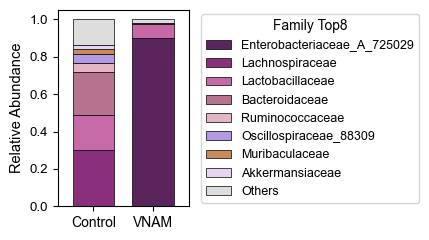

In [179]:
## Family Level - Top 8

df_barplot.plot(kind='bar', stacked=True,figsize=(4.5, 2.5), colormap=darkpurple_axis_rosegold_21, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기
plt.xticks(ticks=range(len(df_barplot.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=10)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=9.5)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=10.5)  #Edit
plt.title('')
plt.legend(title='Family Top8', bbox_to_anchor=(1.05, 1.01), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
plt.savefig('family_rel_top8_v2.png', dpi=500, bbox_inches='tight')
plt.show()